# Apollo 12 LM artificial impact trace

This notebook uses `obspy` to download waveform data for the Apollo 12 Lunar Module artificial impact and remove the instrument sensitivity.

- Event: `12LM` artificial impact
- Impact time: `1969-11-20 22:17:17.7 UTC`
- Station: `S12`
- FDSN network: `XA` (`Apollo Passive Seismic Experiments`)


In [1049]:
# Uncomment this if `obspy` is not installed in the notebook kernel.
# %pip install obspy


In [1050]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
import numpy as np



In [1051]:
def linear_interpolation(trace, interpolation_limit=4):
    """Snippet to interpolate missing data.  

    The SHZ traces have missing data samples 3-4 times every 32 samples. 
    Providing the seed data with these missing data would mean using very 
    large files. Instead, we provide the data with -1 replacing the gaps. 
    To change the files to interpolate across the gaps, use this simple method to 
    replace the -1 values. The trace is modified, and a mask is applied at 
    the end if necessary. 

    :type stream: :class:`~obspy.core.Trace` 
    :param trace: A data trace
    :type interpolation_limit: int 
    :param interpolation_limit: Limit for interpolation. Defaults to 1. For
      more information read the options for the `~pandas.Series.interpolate`
      method. 

    :return: original_mask :class:`~numpy.ndarray` or class:`~numpy.bool_`
       Returns the original mask, before any interpolation is made. 

    """

    data = np.asarray(trace.data, dtype=float)
    original_mask = data == -1
    data[original_mask] = np.nan
    data_series = pd.Series(data)
    data_series.interpolate(
        method='linear',
        axis=0,
        limit=interpolation_limit,
        inplace=True,
        limit_direction='both',
        limit_area='inside',
    )
    trace.data = np.ma.masked_invalid(data_series.to_numpy(dtype=float))
    return original_mask

In [1052]:
def hampel_despike(trace, window_samples=5, n_sigma=6.0):
    """Replace isolated impulsive spikes using a rolling median/MAD test.

    Intended for the narrow one-sample glitches visible in the Apollo MH
    channels. The trace is modified in place and the spike mask is returned.
    """

    data = np.asarray(trace.data, dtype=float)
    if np.ma.isMaskedArray(trace.data):
        data = trace.data.filled(np.nan).astype(float)

    series = pd.Series(data)
    width = 2 * window_samples + 1
    rolling_median = series.rolling(width, center=True, min_periods=1).median()
    abs_dev = (series - rolling_median).abs()
    mad = abs_dev.rolling(width, center=True, min_periods=1).median()
    sigma = 1.4826 * mad

    spike_mask = (abs_dev > n_sigma * sigma) & sigma.notna() & (sigma > 0)
    cleaned = series.copy()
    cleaned.loc[spike_mask] = rolling_median.loc[spike_mask]

    trace.data = cleaned.to_numpy(dtype=float)
    return spike_mask.to_numpy(dtype=bool)


In [1053]:
def select_segment_containing_time(trace, target_time):
    """Return the unmasked SHZ segment containing the target time.

    If no split segment contains the target time, return the longest segment.
    """

    segments = trace.split()
    if len(segments) == 0:
        raise ValueError("No unmasked SHZ segments available after interpolation.")

    for seg in segments:
        if seg.stats.starttime <= target_time <= seg.stats.endtime:
            return seg.copy()

    return max(segments, key=lambda seg: seg.stats.npts).copy()


In [1054]:
def get_trace_if_available(stream, channel):
    matches = stream.select(channel=channel)
    if len(matches) == 0:
        return None
    return matches[0]


In [1055]:
client = Client("IRIS")

impact_time = UTCDateTime("1969-11-20T22:17:17.7")# LM
# impact_time = UTCDateTime("1971-07-29T21:00:00")

starttime = impact_time - 5 * 60
endtime = impact_time + 1*7000

network = "XA"
station = "S12"

print(f"Request window: {starttime} to {endtime}")


Request window: 1969-11-20T22:12:17.700000Z to 1969-11-21T00:13:57.700000Z


In [1056]:
inventory = client.get_stations(
    network=network,
    station=station,
    location="*",
    channel="*",
    starttime=starttime,
    endtime=endtime,
    level="response",
)

display(inventory)


Inventory created at 2026-03-24T09:26:28.618400Z
	Created by: IRIS WEB SERVICE: fdsnws-station | version: 1.1.52
		    http://service.iris.edu/fdsnws/station/1/query?starttime=1969-11-...
	Sending institution: IRIS-DMC (IRIS-DMC)
	Contains:
		Networks (1):
			XA
		Stations (1):
			XA.S12 (ALSEP 12, Oceanus Procellarum, Moon)
		Channels (11):
			XA.S12..ATT, XA.S12..MHZ, XA.S12..MH1, XA.S12..MH2, XA.S12..SHZ, 
			XA.S12.00.MHZ, XA.S12.00.MH1, XA.S12.00.MH2, XA.S12.01.MHZ, 
			XA.S12.01.MH1, XA.S12.01.MH2

In [1057]:
st = client.get_waveforms(
    network=network,
    station=station,
    location="*",
    channel="*",
    starttime=starttime,
    endtime=endtime,
)

st.merge(fill_value="interpolate")

# Only some Apollo traces expose instrument sensitivity metadata.
# For SHZ, interpolate the internal -1 gap markers before removing sensitivity.
# Apply the correction trace by trace and skip unsupported channels.
st_corrected = st.copy()
kept = []
skipped = []
despike_counts = {}

for tr in st_corrected:
    try:
        if tr.stats.channel == "SHZ":
            _ = linear_interpolation(tr, interpolation_limit=4)
        if tr.stats.channel in {"MH1", "MH2", "MHZ"}:
            spike_mask = hampel_despike(tr, window_samples=9, n_sigma=2.0)
            despike_counts[tr.id] = int(spike_mask.sum())
        tr.remove_sensitivity(inventory=inventory)
        kept.append(tr)
    except Exception as exc:
        skipped.append((tr.id, str(exc)))

st_corrected.traces = kept

print(st_corrected)
print("Despiked samples:")
for trace_id, count in despike_counts.items():
    print(f"  {trace_id}: {count}")
print("Skipped traces:")
for trace_id, message in skipped:
    print(f"  {trace_id}: {message}")


4 Trace(s) in Stream:
XA.S12..SHZ   | 1969-11-20T22:12:17.701608Z - 1969-11-21T00:13:57.701608Z | 53.0 Hz, 386901 samples (masked)
XA.S12.00.MH1 | 1969-11-20T22:12:17.780477Z - 1969-11-21T00:13:57.705005Z | 6.6 Hz, 48363 samples
XA.S12.00.MH2 | 1969-11-20T22:12:17.799477Z - 1969-11-21T00:13:57.724005Z | 6.6 Hz, 48363 samples
XA.S12.00.MHZ | 1969-11-20T22:12:17.818477Z - 1969-11-21T00:13:57.592062Z | 6.6 Hz, 48362 samples
Despiked samples:
  XA.S12.00.MH1: 868
  XA.S12.00.MH2: 849
  XA.S12.00.MHZ: 1270
Skipped traces:
  XA.S12..ATT: 'NoneType' object has no attribute 'value'


In [1058]:
trace_summary = pd.DataFrame(
    [
        {
            "id": tr.id,
            "starttime": str(tr.stats.starttime),
            "endtime": str(tr.stats.endtime),
            "sampling_rate_hz": tr.stats.sampling_rate,
            "npts": tr.stats.npts,
        }
        for tr in st_corrected
    ]
).sort_values("id").reset_index(drop=True)

display(trace_summary)


,id,starttime,endtime,sampling_rate_hz,npts
0,XA.S12..SHZ,1969-11-20T22:12:17.701608Z,1969-11-21T00:13:57.701608Z,53.000,386901
1,XA.S12.00.MH1,1969-11-20T22:12:17.780477Z,1969-11-21T00:13:57.705005Z,6.625,48363
2,XA.S12.00.MH2,1969-11-20T22:12:17.799477Z,1969-11-21T00:13:57.724005Z,6.625,48363
3,XA.S12.00.MHZ,1969-11-20T22:12:17.818477Z,1969-11-21T00:13:57.592062Z,6.625,48362


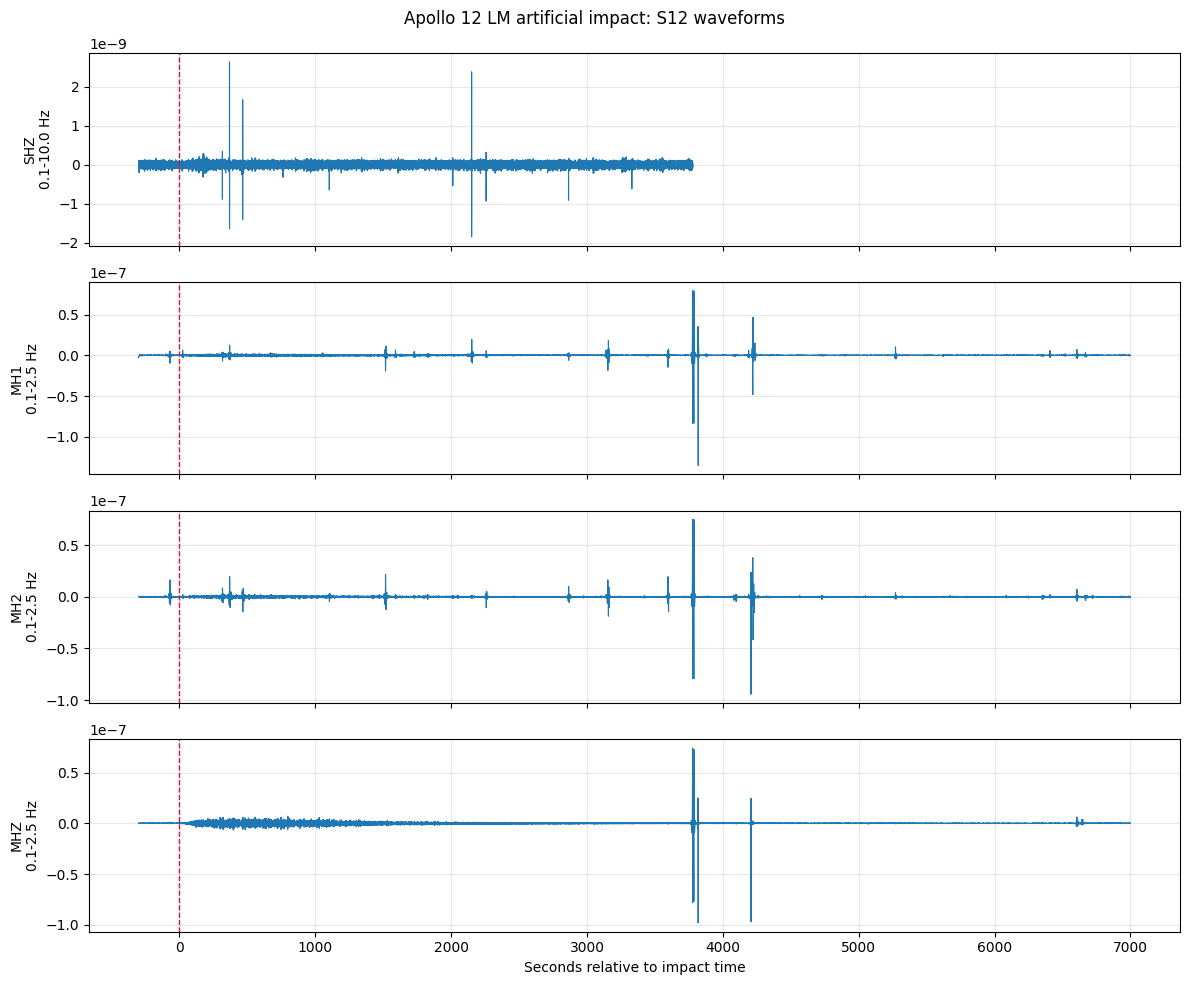

In [1059]:
channels_to_plot = ["SHZ", "MH1", "MH2", "MHZ"]
filter_settings = {
    "SHZ": dict(freqmin=0.1, freqmax=10.0),
    "MH1": dict(freqmin=0.1, freqmax=2.5),
    "MH2": dict(freqmin=0.1, freqmax=2.5),
    "MHZ": dict(freqmin=0.1, freqmax=2.5),
}
available_channels = [
    channel for channel in channels_to_plot
    if get_trace_if_available(st_corrected, channel) is not None
]

if len(available_channels) == 0:
    raise ValueError("No requested channels are available in the selected time window.")

fig, axes = plt.subplots(len(available_channels), 1, figsize=(12, 2.5 * len(available_channels)), sharex=True)
if len(available_channels) == 1:
    axes = [axes]

for ax, channel in zip(axes, available_channels):
    trace = select_segment_containing_time(
        get_trace_if_available(st_corrected, channel),
        impact_time,
    )
    trace.detrend("demean")

    filt = filter_settings[channel]
    trace.filter(
        "bandpass",
        freqmin=filt["freqmin"],
        freqmax=filt["freqmax"],
        corners=4,
        zerophase=True,
    )

    time_seconds = trace.times(reftime=impact_time)
    ax.plot(time_seconds, trace.data, lw=0.8)
    ax.axvline(0.0, color="crimson", ls="--", lw=1)
    ax.set_ylabel(f"{channel}\n{filt['freqmin']}-{filt['freqmax']} Hz")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Seconds relative to impact time")
fig.suptitle("Apollo 12 LM artificial impact: S12 waveforms")
fig.tight_layout()
plt.show()


In [1060]:
from scipy.signal import butter, sosfiltfilt, hilbert, get_window
def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms

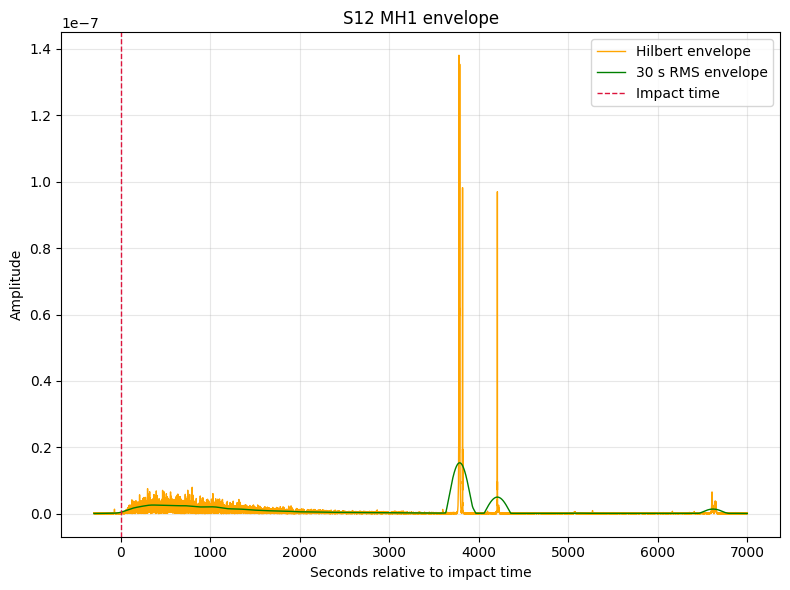

In [1061]:
mhz_source = get_trace_if_available(st_corrected, "MHZ")
if mhz_source is None:
    raise ValueError("MHZ is not available in the selected time window.")

mhz_trace = select_segment_containing_time(mhz_source, impact_time).copy()
mhz_trace.detrend("demean")

filt = filter_settings["MHZ"]
env, rms = env_and_rms(
    np.asarray(mhz_trace.data, dtype=float),
    mhz_trace.stats.sampling_rate,
    fl=filt["freqmin"],
    fu=filt["freqmax"],
    win_s=300,
    order=4,
)
time_seconds = mhz_trace.times(reftime=impact_time)

fig, ax = plt.subplots(figsize=(8 ,6))
ax.plot(time_seconds, env, color="orange", lw=1.0, label="Hilbert envelope")
ax.plot(time_seconds, rms, color="green", lw=1.0, label="30 s RMS envelope")
ax.axvline(0.0, color="crimson", ls="--", lw=1, label="Impact time")
ax.set_title("S12 MH1 envelope")
ax.set_xlabel("Seconds relative to impact time")
ax.set_ylabel("Amplitude")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()


In [1062]:
from scipy.optimize import least_squares

# Event metadata for the current envelope fit.
# Update these if you switch to a different impact.
EVENT_NAME = "Apollo 15 S-IVB impact"
SOURCE_LAT_DEG = -1.2897
SOURCE_LON_DEG = -11.8245
STATION_COORDS = {
    "S12": dict(lat=-3.00942, lon=-23.42458),
}

MOON_RADIUS_KM = 1737.4
EQ14_FIT_START_S = 0.0
EQ14_FIT_END_S = 150.0
EQ14_NOISE_START_S = -150.0
EQ14_NOISE_END_S = -30.0
EQ14_MIN_NOISE_N = 40
EQ14_MIN_FIT_N = 80
EQ14_T_EPS_SEC = 1.0
EQ14_P0 = np.array([6.0, 2.0, 1.0, 10.0], float)
EQ14_LOWER = np.array([-16.0, 0.001, 0.001, 0.1], float)
EQ14_UPPER = np.array([16.0, 10.0, 5.0, 500.0], float)

def moon_great_circle_distance_km(lat1_deg, lon1_deg, lat2_deg, lon2_deg, radius_km=MOON_RADIUS_KM):
    lat1 = np.deg2rad(lat1_deg)
    lon1 = np.deg2rad(lon1_deg)
    lat2 = np.deg2rad(lat2_deg)
    lon2 = np.deg2rad(lon2_deg)
    cos_delta = np.sin(lat1) * np.sin(lat2) + np.cos(lat1) * np.cos(lat2) * np.cos(lon1 - lon2)
    cos_delta = np.clip(cos_delta, -1.0, 1.0)
    return float(radius_km * np.arccos(cos_delta))

def stable_log10(values):
    values = np.asarray(values, float)
    positive = values[values > 0]
    floor = 1e-12 if positive.size == 0 else min(1e-12, max(1e-300, 0.1 * np.min(positive)))
    return np.log10(np.clip(values, floor, None))

def estimate_noise_level(time_s, amplitude, noise_start, noise_end, min_noise_n):
    mask = np.isfinite(time_s) & np.isfinite(amplitude) & (amplitude > 0) & (time_s >= noise_start) & (time_s <= noise_end)
    if mask.sum() < min_noise_n:
        raise RuntimeError("Not enough points in pre-event noise window")
    return float(np.median(amplitude[mask]))

def evaluate_eq14_energy(time_s, log10_A, q0, alpha, sigma_km, distance_km):
    time_s = np.clip(np.asarray(time_s, float), EQ14_T_EPS_SEC, None)
    A = 10 ** log10_A
    q = 1.0 - 10 ** (-q0)
    q = np.clip(q, 1e-6, 0.999999)
    sigma_km = max(1e-6, sigma_km)
    alpha = max(1e-6, alpha)
    return (A ** 2) * np.exp(alpha * time_s * np.log(q)) * (1.0 / (alpha * time_s)) * np.exp(-((distance_km / sigma_km) ** 2) / (alpha * time_s))

def evaluate_eq14_snr(time_s, log10_A, q0, alpha, sigma_km, distance_km):
    return 1.0 + np.sqrt(evaluate_eq14_energy(time_s, log10_A, q0, alpha, sigma_km, distance_km))

def fit_eq14_to_snr(time_s, snr_env, *, distance_km, fit_start, fit_end, min_fit_n):
    time_s = np.asarray(time_s, float)
    snr_env = np.asarray(snr_env, float)
    mask = np.isfinite(time_s) & np.isfinite(snr_env) & (snr_env > 0) & (time_s >= fit_start) & (time_s <= fit_end)
    if mask.sum() < min_fit_n:
        raise RuntimeError("Not enough points in fit window")

    t_fit = time_s[mask] - fit_start
    y_fit = stable_log10(snr_env[mask])

    def residuals(params):
        model = evaluate_eq14_snr(t_fit, params[0], params[1], params[2], params[3], distance_km)
        return stable_log10(model) - y_fit

    result = least_squares(residuals, EQ14_P0, bounds=(EQ14_LOWER, EQ14_UPPER), method="trf", max_nfev=4000)
    if not result.success:
        raise RuntimeError(result.message)

    log10_A, q0, alpha, sigma_km = result.x
    ssr = float(np.dot(result.fun, result.fun))
    rmse = float(np.sqrt(ssr / result.fun.size))
    t_model = np.linspace(fit_start, fit_end, 2000)
    snr_model = evaluate_eq14_snr(t_model - fit_start, log10_A, q0, alpha, sigma_km, distance_km)
    return dict(log10_A=float(log10_A), q0=float(q0), alpha=float(alpha), sigma_km=float(sigma_km), rmse=float(rmse), t_model=t_model, snr_model=snr_model)


,event,station,channel,distance_km,noise_level,log10_A,q0,alpha,sigma_km,rmse
0,Apollo 15 S-IVB impact,S12,MHZ,355.338949,1.681302e-10,1.364979,6.209378,0.049048,173.559751,0.152213


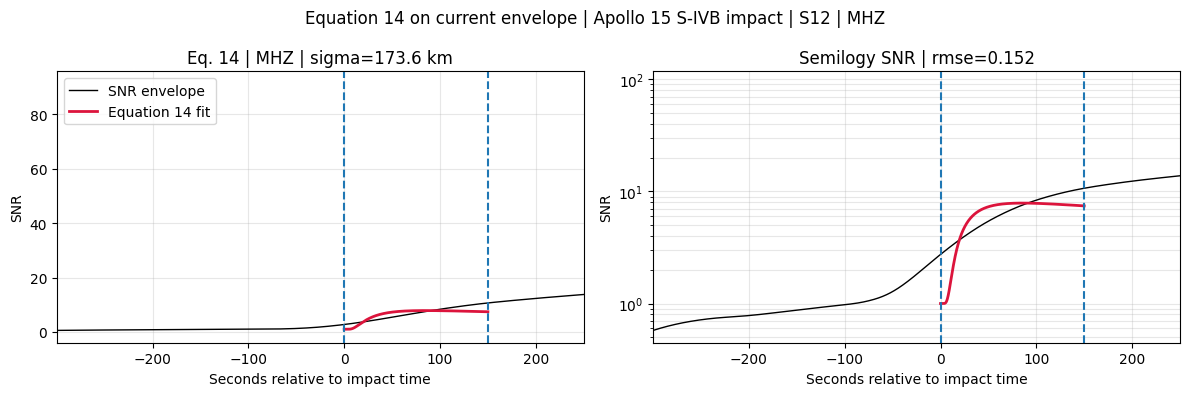

In [1063]:
# Apply equation 14 to the current single-channel envelope from the cell above.
# This uses the RMS-smoothed envelope, normalized by the pre-event noise level.

current_channel = mhz_trace.stats.channel
station_name = station
station_meta = STATION_COORDS[station_name]
distance_km = moon_great_circle_distance_km(
    SOURCE_LAT_DEG,
    SOURCE_LON_DEG,
    station_meta["lat"],
    station_meta["lon"],
)

fit_end_s = min(EQ14_FIT_END_S, float(np.nanmax(time_seconds)) - 1e-6)
noise_level = estimate_noise_level(
    time_seconds,
    rms,
    EQ14_NOISE_START_S,
    EQ14_NOISE_END_S,
    EQ14_MIN_NOISE_N,
)
snr_env = rms / noise_level
eq14_fit = fit_eq14_to_snr(
    time_seconds,
    snr_env,
    distance_km=distance_km,
    fit_start=EQ14_FIT_START_S,
    fit_end=fit_end_s,
    min_fit_n=EQ14_MIN_FIT_N,
)

fit_summary = pd.DataFrame([
    dict(
        event=EVENT_NAME,
        station=station_name,
        channel=current_channel,
        distance_km=distance_km,
        noise_level=noise_level,
        log10_A=eq14_fit["log10_A"],
        q0=eq14_fit["q0"],
        alpha=eq14_fit["alpha"],
        sigma_km=eq14_fit["sigma_km"],
        rmse=eq14_fit["rmse"],
    )
])
display(fit_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(time_seconds, snr_env, color="k", lw=1, label="SNR envelope")
axes[0].plot(eq14_fit["t_model"], eq14_fit["snr_model"], color="crimson", lw=2, label="Equation 14 fit")
axes[0].axvline(EQ14_FIT_START_S, ls="--", color="tab:blue")
axes[0].axvline(fit_end_s, ls="--", color="tab:blue")
axes[0].set_xlim(float(np.nanmin(time_seconds)), min(float(np.nanmax(time_seconds)), max(250.0, fit_end_s + 10.0)))
axes[0].set_xlabel("Seconds relative to impact time")
axes[0].set_ylabel("SNR")
axes[0].set_title(f"Eq. 14 | {current_channel} | sigma={eq14_fit['sigma_km']:.1f} km")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(time_seconds, snr_env, color="k", lw=1, label="SNR envelope")
axes[1].semilogy(eq14_fit["t_model"], eq14_fit["snr_model"], color="crimson", lw=2, label="Equation 14 fit")
axes[1].axvline(EQ14_FIT_START_S, ls="--", color="tab:blue")
axes[1].axvline(fit_end_s, ls="--", color="tab:blue")
axes[1].set_xlim(float(np.nanmin(time_seconds)), min(float(np.nanmax(time_seconds)), max(250.0, fit_end_s + 10.0)))
axes[1].set_xlabel("Seconds relative to impact time")
axes[1].set_ylabel("SNR")
axes[1].set_title(f"Semilogy SNR | rmse={eq14_fit['rmse']:.3f}")
axes[1].grid(True, which="both", alpha=0.3)

fig.suptitle(f"Equation 14 on current envelope | {EVENT_NAME} | {station_name} | {current_channel}")
fig.tight_layout()
plt.show()


,event,channel,fit_start_s,fit_end_requested_s,fit_end_s,fetch_end_offset_s,noise_level,distance_km,log10_A,q0,alpha,sigma_km,rmse
0,Apollo 12 LM impact,MHZ,-150.0,150.0,150.000000,2000.0,1.681311e-10,73.005915,3.174608,2.692547,0.665514,2.482504,0.015816
1,Apollo 12 LM impact,MHZ,-150.0,2000.0,1999.892061,2000.0,1.681311e-10,73.005915,3.216767,2.290480,0.461649,2.888337,0.032483
2,Apollo 15 S-IVB impact,MH1,-150.0,150.0,150.000000,7000.0,1.839547e-10,355.338949,4.428980,2.469961,0.770017,9.091845,0.004321
3,Apollo 15 S-IVB impact,MH1,-150.0,7000.0,6999.857473,7000.0,1.839547e-10,355.338949,4.052978,2.869037,0.905133,9.117054,0.046208


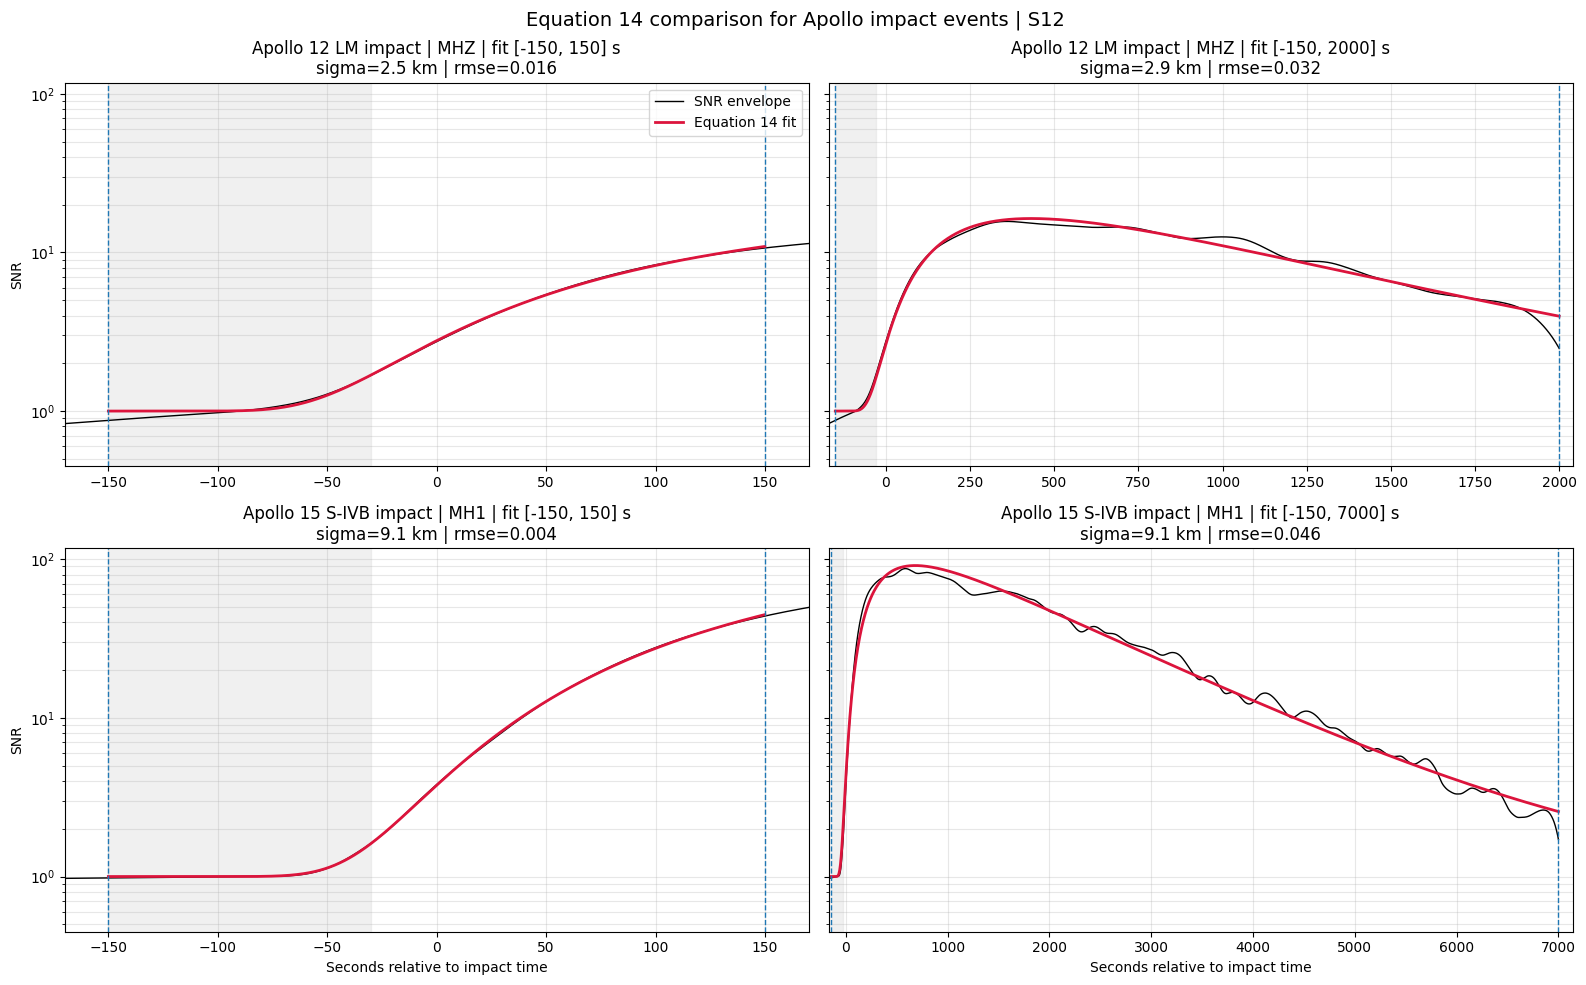

In [1068]:
# Compare equation 14 fits for the Apollo 12 LM and Apollo 15 S-IVB impacts.
# Row order defines the requested subplot order: first event, then second event.

COMPARISON_EVENTS = [
    {
        "event_name": "Apollo 12 LM impact",
        "impact_time": UTCDateTime("1969-11-20T22:17:17.7"),
        "source_lat_deg": -3.94,
        "source_lon_deg": -21.20,
        "channel": "MHZ",
        "fetch_end_offset_s": 2000.0,
        "fit_windows": [(-150.0, 150.0), (-150.0, 2000.0)],
    },
    {
        "event_name": "Apollo 15 S-IVB impact",
        "impact_time": UTCDateTime("1971-07-29T20:58:42.9"),
        "source_lat_deg": -1.2897,
        "source_lon_deg": -11.8245,
        "channel": "MH1",
        "fetch_end_offset_s": 7000.0,
        "fit_windows": [(-150.0, 150.0), (-150.0, 7000.0)],
    },
]
COMPARISON_RMS_WIN_S = 300.0


def prepare_event_snr_envelope(event_cfg, *, rms_win_s):
    event_time = event_cfg["impact_time"]
    event_starttime = event_time - 5 * 60
    event_endtime = event_time + event_cfg["fetch_end_offset_s"]

    event_inventory = client.get_stations(
        network=network,
        station=station,
        location="*",
        channel="*",
        starttime=event_starttime,
        endtime=event_endtime,
        level="response",
    )
    event_stream = client.get_waveforms(
        network=network,
        station=station,
        location="*",
        channel="*",
        starttime=event_starttime,
        endtime=event_endtime,
    )
    event_stream.merge(fill_value="interpolate")

    corrected_stream = event_stream.copy()
    kept_traces = []
    for tr in corrected_stream:
        try:
            if tr.stats.channel == "SHZ":
                _ = linear_interpolation(tr, interpolation_limit=4)
            if tr.stats.channel in {"MH1", "MH2", "MHZ"}:
                _ = hampel_despike(tr, window_samples=9, n_sigma=2.0)
            tr.remove_sensitivity(inventory=event_inventory)
            kept_traces.append(tr)
        except Exception:
            continue
    corrected_stream.traces = kept_traces

    trace_source = get_trace_if_available(corrected_stream, event_cfg["channel"])
    if trace_source is None:
        raise ValueError(f"{event_cfg['channel']} is not available for {event_cfg['event_name']}")

    trace = select_segment_containing_time(trace_source, event_time).copy()
    trace.detrend("demean")

    filt = filter_settings[event_cfg["channel"]]
    env, rms_env = env_and_rms(
        np.asarray(trace.data, dtype=float),
        trace.stats.sampling_rate,
        fl=filt["freqmin"],
        fu=filt["freqmax"],
        win_s=rms_win_s,
        order=4,
    )
    rel_time_s = trace.times(reftime=event_time)
    noise_level = estimate_noise_level(
        rel_time_s,
        rms_env,
        EQ14_NOISE_START_S,
        EQ14_NOISE_END_S,
        EQ14_MIN_NOISE_N,
    )
    snr_env = rms_env / noise_level
    distance_km = moon_great_circle_distance_km(
        event_cfg["source_lat_deg"],
        event_cfg["source_lon_deg"],
        STATION_COORDS[station]["lat"],
        STATION_COORDS[station]["lon"],
    )
    return {
        "time_seconds": rel_time_s,
        "snr_env": snr_env,
        "distance_km": distance_km,
        "noise_level": float(noise_level),
        "channel": trace.stats.channel,
        "env": env,
        "rms": rms_env,
    }


comparison_rows = []
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

for row_idx, event_cfg in enumerate(COMPARISON_EVENTS):
    prepared = prepare_event_snr_envelope(event_cfg, rms_win_s=COMPARISON_RMS_WIN_S)
    time_seconds = prepared["time_seconds"]
    snr_env = prepared["snr_env"]
    distance_km = prepared["distance_km"]
    max_time_s = float(np.nanmax(time_seconds)) - 1e-6

    for col_idx, (fit_start_s, fit_end_requested_s) in enumerate(event_cfg["fit_windows"]):
        fit_end_s = min(fit_end_requested_s, max_time_s)
        eq14_fit = fit_eq14_to_snr(
            time_seconds,
            snr_env,
            distance_km=distance_km,
            fit_start=fit_start_s,
            fit_end=fit_end_s,
            min_fit_n=EQ14_MIN_FIT_N,
        )

        ax = axes[row_idx, col_idx]
        ax.semilogy(time_seconds, snr_env, color="k", lw=1.0, label="SNR envelope")
        ax.semilogy(eq14_fit["t_model"], eq14_fit["snr_model"], color="crimson", lw=2.0, label="Equation 14 fit")
        ax.axvspan(EQ14_NOISE_START_S, EQ14_NOISE_END_S, color="0.9", alpha=0.6)
        ax.axvline(fit_start_s, ls="--", color="tab:blue", lw=1.0)
        ax.axvline(fit_end_s, ls="--", color="tab:blue", lw=1.0)
        ax.set_xlim(EQ14_NOISE_START_S - 20.0, fit_end_requested_s + max(20.0, 0.02 * fit_end_requested_s))
        ax.grid(True, which="both", alpha=0.3)
        ax.set_title(
            f"{event_cfg['event_name']} | {prepared['channel']} | fit [{fit_start_s:.0f}, {fit_end_requested_s:.0f}] s\n"
            f"sigma={eq14_fit['sigma_km']:.1f} km | rmse={eq14_fit['rmse']:.3f}"
        )
        if row_idx == len(COMPARISON_EVENTS) - 1:
            ax.set_xlabel("Seconds relative to impact time")
        if col_idx == 0:
            ax.set_ylabel("SNR")
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right")

        comparison_rows.append(
            {
                "event": event_cfg["event_name"],
                "channel": prepared["channel"],
                "fit_start_s": fit_start_s,
                "fit_end_requested_s": fit_end_requested_s,
                "fit_end_s": fit_end_s,
                "fetch_end_offset_s": event_cfg["fetch_end_offset_s"],
                "noise_level": prepared["noise_level"],
                "distance_km": distance_km,
                "log10_A": eq14_fit["log10_A"],
                "q0": eq14_fit["q0"],
                "alpha": eq14_fit["alpha"],
                "sigma_km": eq14_fit["sigma_km"],
                "rmse": eq14_fit["rmse"],
            }
        )

comparison_summary = pd.DataFrame(comparison_rows)
display(comparison_summary)

fig.suptitle("Equation 14 comparison for Apollo impact events | S12", fontsize=14)
fig.tight_layout()
plt.show()


In [1069]:
# Estimate equation 15 sigma0 and beta from the comparison-fit sigmas.
# Equation 15 form: sigma(D) = sigma0 * (D / D0)^beta
# This uses the sigma_km values stored in comparison_summary by the previous cell.
# Two regression cases are reported:
#   - 150 s: rows fitted with the short window ending at 150 s
#   - full_waveform: rows fitted with each event-specific long window

if "comparison_summary" not in globals():
    raise RuntimeError("Run the previous comparison-fit cell first.")

EQ15_D0_KM = 100.0

eq15_input = comparison_summary.loc[
    (comparison_summary["distance_km"] > 0) & (comparison_summary["sigma_km"] > 0),
    ["event", "channel", "fit_start_s", "fit_end_requested_s", "fit_end_s", "distance_km", "sigma_km", "rmse"],
].copy()
if len(eq15_input) < 2:
    raise RuntimeError("Need at least two positive sigma-distance pairs to estimate sigma0 and beta.")

eq15_input["fit_case"] = np.where(
    np.isclose(eq15_input["fit_end_requested_s"], 150.0),
    "150 s",
    "full_waveform",
)

print(f"Equation 15 regression reference distance D0 = {EQ15_D0_KM:.1f} km")
print()

eq15_results = []
for fit_case, group in eq15_input.groupby("fit_case", sort=False):
    group = group.sort_values("distance_km").reset_index(drop=True)
    if len(group) < 2:
        print(f"fit_case = {fit_case}: not enough events to fit equation 15.")
        continue

    x = np.log(group["distance_km"] / EQ15_D0_KM)
    y = np.log(group["sigma_km"])
    beta_eq15, log_sigma0_eq15 = np.polyfit(x, y, 1)
    sigma0_eq15 = float(np.exp(log_sigma0_eq15))

    group["log_D_over_D0"] = x
    group["log_sigma_km"] = y
    group["sigma_pred_eq15"] = sigma0_eq15 * (group["distance_km"] / EQ15_D0_KM) ** beta_eq15
    group["residual_log_eq15"] = group["log_sigma_km"] - np.log(group["sigma_pred_eq15"])
    rmse_log_eq15 = float(np.sqrt(np.mean(group["residual_log_eq15"] ** 2)))

    print(f"fit_case = {fit_case}")
    print(f"sigma(D) = {sigma0_eq15:.3f} * (D / {EQ15_D0_KM:.1f} km)^{beta_eq15:.3f}")
    print(f"Estimated sigma0 = {sigma0_eq15:.3f} km")
    print(f"Estimated beta = {beta_eq15:.3f}")
    print(f"Log-space RMSE = {rmse_log_eq15:.4f}")
    display(group)
    print()

    eq15_results.append(
        {
            "fit_case": fit_case,
            "sigma0_km": sigma0_eq15,
            "beta": float(beta_eq15),
            "rmse_log": rmse_log_eq15,
            "n_events": int(len(group)),
        }
    )

eq15_results_df = pd.DataFrame(eq15_results)
display(eq15_results_df)


Equation 15 regression reference distance D0 = 100.0 km

fit_case = 150 s
sigma(D) = 3.213 * (D / 100.0 km)^0.820
Estimated sigma0 = 3.213 km
Estimated beta = 0.820
Log-space RMSE = 0.0000


,event,channel,fit_start_s,fit_end_requested_s,fit_end_s,distance_km,sigma_km,rmse,fit_case,log_D_over_D0,log_sigma_km,sigma_pred_eq15,residual_log_eq15
0,Apollo 12 LM impact,MHZ,-150.0,150.0,150.0,73.005915,2.482504,0.015816,150 s,-0.314630,0.909268,2.482504,0.000000e+00
1,Apollo 15 S-IVB impact,MH1,-150.0,150.0,150.0,355.338949,9.091845,0.004321,150 s,1.267902,2.207378,9.091845,-4.440892e-16



fit_case = full_waveform
sigma(D) = 3.630 * (D / 100.0 km)^0.726
Estimated sigma0 = 3.630 km
Estimated beta = 0.726
Log-space RMSE = 0.0000


,event,channel,fit_start_s,fit_end_requested_s,fit_end_s,distance_km,sigma_km,rmse,fit_case,log_D_over_D0,log_sigma_km,sigma_pred_eq15,residual_log_eq15
0,Apollo 12 LM impact,MHZ,-150.0,2000.0,1999.892061,73.005915,2.888337,0.032483,full_waveform,-0.314630,1.060681,2.888337,0.000000e+00
1,Apollo 15 S-IVB impact,MH1,-150.0,7000.0,6999.857473,355.338949,9.117054,0.046208,full_waveform,1.267902,2.210147,9.117054,-4.440892e-16


,fit_case,sigma0_km,beta,rmse_log,n_events
0,150 s,3.213467,0.820274,3.140185e-16,2
1,full_waveform,3.629921,0.726346,3.140185e-16,2


In [ ]:
# Refit the Apollo 12 LM and Apollo 15 S-IVB impacts with windows starting at -30 s.
# Subplot order is fixed as requested: first event on the top row, second event on the bottom row.

COMPARISON_EVENTS_MINUS30 = [
    {
        "event_name": "Apollo 12 LM impact",
        "impact_time": UTCDateTime("1969-11-20T22:17:17.7"),
        "source_lat_deg": -3.94,
        "source_lon_deg": -21.20,
        "channel": "MHZ",
        "fetch_end_offset_s": 7000.0,
        "fit_windows": [(-30.0, 150.0), (-30.0, 7000.0)],
    },
    {
        "event_name": "Apollo 15 S-IVB impact",
        "impact_time": UTCDateTime("1971-07-29T20:58:42.9"),
        "source_lat_deg": -1.2897,
        "source_lon_deg": -11.8245,
        "channel": "MH1",
        "fetch_end_offset_s": 7000.0,
        "fit_windows": [(-30.0, 150.0), (-30.0, 7000.0)],
    },
]

comparison_rows_minus30 = []
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

for row_idx, event_cfg in enumerate(COMPARISON_EVENTS_MINUS30):
    prepared = prepare_event_snr_envelope(event_cfg, rms_win_s=COMPARISON_RMS_WIN_S)
    time_seconds = prepared["time_seconds"]
    snr_env = prepared["snr_env"]
    distance_km = prepared["distance_km"]
    max_time_s = float(np.nanmax(time_seconds)) - 1e-6

    for col_idx, (fit_start_s, fit_end_requested_s) in enumerate(event_cfg["fit_windows"]):
        fit_end_s = min(fit_end_requested_s, max_time_s)
        eq14_fit = fit_eq14_to_snr(
            time_seconds,
            snr_env,
            distance_km=distance_km,
            fit_start=fit_start_s,
            fit_end=fit_end_s,
            min_fit_n=EQ14_MIN_FIT_N,
        )

        ax = axes[row_idx, col_idx]
        ax.semilogy(time_seconds, snr_env, color="k", lw=1.0, label="SNR envelope")
        ax.semilogy(eq14_fit["t_model"], eq14_fit["snr_model"], color="crimson", lw=2.0, label="Equation 14 fit")
        ax.axvspan(EQ14_NOISE_START_S, EQ14_NOISE_END_S, color="0.9", alpha=0.6)
        ax.axvline(fit_start_s, ls="--", color="tab:blue", lw=1.0)
        ax.axvline(fit_end_s, ls="--", color="tab:blue", lw=1.0)
        ax.set_xlim(EQ14_NOISE_START_S - 20.0, fit_end_requested_s + max(20.0, 0.02 * fit_end_requested_s))
        ax.grid(True, which="both", alpha=0.3)

        title = (
            f"{event_cfg['event_name']} | {prepared['channel']} | fit [{fit_start_s:.0f}, {fit_end_requested_s:.0f}] s\n"
            f"sigma={eq14_fit['sigma_km']:.1f} km | rmse={eq14_fit['rmse']:.3f}"
        )
        if not np.isclose(fit_end_s, fit_end_requested_s):
            title += f" | used {fit_end_s:.0f} s"
        ax.set_title(title)

        if row_idx == len(COMPARISON_EVENTS_MINUS30) - 1:
            ax.set_xlabel("Seconds relative to impact time")
        if col_idx == 0:
            ax.set_ylabel("SNR")
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc="upper right")

        comparison_rows_minus30.append(
            {
                "event": event_cfg["event_name"],
                "channel": prepared["channel"],
                "fit_start_s": fit_start_s,
                "fit_end_requested_s": fit_end_requested_s,
                "fit_end_s": fit_end_s,
                "fetch_end_offset_s": event_cfg["fetch_end_offset_s"],
                "noise_level": prepared["noise_level"],
                "distance_km": distance_km,
                "log10_A": eq14_fit["log10_A"],
                "q0": eq14_fit["q0"],
                "alpha": eq14_fit["alpha"],
                "sigma_km": eq14_fit["sigma_km"],
                "rmse": eq14_fit["rmse"],
            }
        )

comparison_summary_minus30 = pd.DataFrame(comparison_rows_minus30)
display(comparison_summary_minus30)

fig.suptitle("Equation 14 comparison with fit windows starting at -30 s | S12", fontsize=14)
fig.tight_layout()
plt.show()
